# KPI réseau télécom mensuels : barres d'utilisation de données avec lignes ARPU et résiliation (PROC GBARLINE)

## Résumé exécutif

Ce notebook utilise **PROC GBARLINE** pour combiner un graphique à barres verticales de l'utilisation mensuelle de données mobiles avec des tracés en ligne superposés d'ARPU, de résiliation et de tickets de support — le tableau de bord KPI classique « à deux axes » qu'un analyste télécom construit pour repérer si la hausse de l'utilisation se traduit réellement en revenu et en fidélisation. Il génère des enregistrements synthétiques par abonné en ligne, puis exploite les instructions BAR et LINE avec des sous-groupes, des axes droits personnalisés, des symboles de référence, et des légendes.

## Sources de données

**Jeu de données : `telco_kpi`** — enregistrements synthétiques par abonné-mois (4 mois x 3 forfaits x 8 abonnés = 96 lignes), générés en ligne avec `call streaminit(20260531)`. Le panel est maintenu à 96 lignes afin de tenir confortablement dans la limite de 100 observations du mode sans licence, laissant chaque mois et chaque forfait entièrement peuplés.

| Variable | Type | Description |
|----------|------|-------------|
| `month`  | Car  | Libellé du mois calendaire (Jan–Avr) |
| `plan`   | Car  | Forfait : Prépayé, Postpayé, Famille |
| `data_gb`| Num  | Données mobiles consommées mensuellement, en Go (distribution gamma, avec une légère hausse saisonnière et une croissance lente) |
| `arpu`   | Num  | Revenu moyen par utilisateur, en USD (augmente avec le niveau de forfait et au fil des mois) |
| `churn`  | Num  | Indicateur de résiliation mensuel (0/1, Bernoulli ; plus élevé en début de période et sur les forfaits d'entrée de gamme) |
| `tickets`| Num  | Tickets de support ouverts (comptage de Poisson) |

# KPI réseau télécom mensuels avec PROC GBARLINE

Les opérateurs télécom vivent et meurent par une poignée de KPI mensuels : la quantité de **données** consommées par les abonnés, l'**ARPU** (revenu moyen par utilisateur) que cette consommation génère, le nombre de clients en **résiliation**, et la charge de **tickets de support** derrière tout cela. Ces métriques vivent sur des échelles très différentes — gigaoctets, dollars, et petits comptages — donc les tracer sur un seul axe de réponse masque l'histoire.

`PROC GBARLINE` est conçu exactement pour cela : il trace un graphique à **barres** verticales sur l'axe gauche et superpose une ou plusieurs courbes de **ligne** sur un axe droit indépendant. Dans ce notebook, nous construisons un tableau de bord utilisation-vs-revenu, puis superposons progressivement des sous-groupes par forfait, un axe droit personnalisé, et des superpositions multi-lignes.

## Étape 1 — Générer des données synthétiques abonné-mois

L'étape DATA ci-dessous fabrique un panel réaliste : 4 mois (Jan–Avr) sur 3 forfaits (Prépayé, Postpayé, Famille) avec 8 abonnés chacun, pour 96 lignes au total. Nous initialisons le générateur aléatoire avec `call streaminit` pour la reproductibilité et tirons chaque KPI d'une distribution adaptée au domaine :

- **L'utilisation de données** suit une distribution gamma avec une légère hausse saisonnière et une croissance lente d'un mois sur l'autre.
- **L'ARPU** augmente avec le niveau de forfait et au fil des mois, avec un bruit normal.
- **La résiliation** est un indicateur de Bernoulli plus élevé en début de période et sur les forfaits moins chers.
- **Les tickets de support** suivent des comptages de Poisson, un peu plus lourds en début de période.

Aucun fichier externe n'est lu — tout est autonome, et le panel de 96 lignes reste dans la limite de 100 observations du mode sans licence afin que chaque mois et chaque forfait s'affiche.

In [1]:
DONNÉES telco_kpi;
    APPELER streaminit(20260531);
    LONGUEUR month $3 plan $12;
    TABLEAU mname[4] $3 _temporary_
        ('Jan' 'Fev' 'Mar' 'Avr');
    FAIRE mi = 1 JUSQU_À 4;
        month = mname[mi];
        /* légère hausse saisonnière et croissance lente des données */
        season = 1 + 0.10*sin((mi-1)/12*2*3.14159);
        FAIRE plan_i = 1 JUSQU_À 3;
            SI plan_i = 1 ALORS plan = 'Prépayé';
            SINON SI plan_i = 2 ALORS plan = 'Postpayé';
            SINON plan = 'Famille';
            FAIRE rep = 1 JUSQU_À 8;
                /* données mobiles mensuelles consommées (Go) */
                data_gb = rand('gamma', 4) * 3 * season
                          + (mi * 0.4);
                /* revenu moyen par utilisateur ($) */
                arpu = 28 + 6*plan_i + rand('normal', 0, 4)
                       + mi*0.3;
                /* indicateur de résiliation mensuel, plus élevé en début d'année */
                churn = rand('bernoulli',
                             0.18 - 0.03*plan_i + 0.02*(4-mi));
                /* tickets de support ouverts */
                tickets = rand('poisson', 1.6 + 0.15*(4-mi));
                SORTIE;
            FIN;
        FIN;
    FIN;
    SUPPRIMER mi plan_i rep season mname:;
EXÉCUTER;


NOTE: DATA telco_kpi


NOTE: Wrote telco_kpi (96 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds


## Étape 2 — Le tableau de bord central : barres d'utilisation + ligne ARPU

C'est le schéma canonique de `GBARLINE`. L'instruction `BAR` trace l'utilisation moyenne mensuelle de données (`SUMVAR=data_gb TYPE=mean`), et une seule instruction `LINE` superpose l'ARPU moyen sur l'axe droit (`STAT=mean TYPE=join`). Nous activons ODS Graphics et donnons au graphique un titre sur deux lignes. `COUTLINE=` et `WIDTH=` mettent en forme les barres.

                                    Utilisation mensuelle de données mobiles et ARPU                                    
                                            KPI réseau télécom synthétiques                                             




NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: Option TITLE changed to Utilisation mensuelle de données mobiles et ARPU.
NOTE: Option TITLE2 changed to KPI réseau télécom synthétiques.
NOTE: PROC GBARLINE data=telco_kpi

NOTE: ODS plot written: gbarline.spec.json


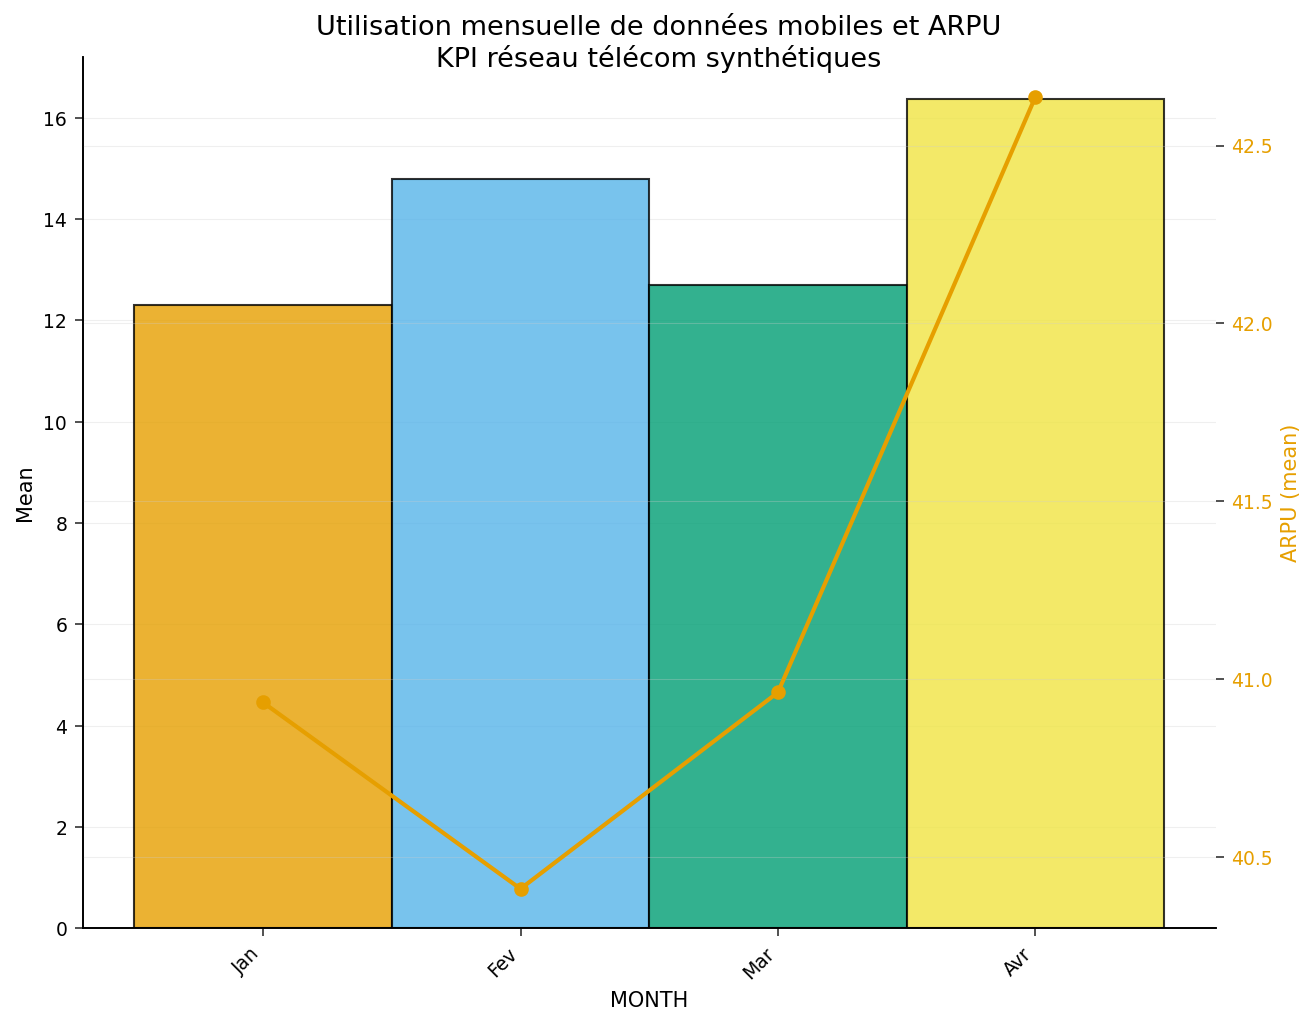

In [2]:
ODS GRAPHICS SUR;
TITRE 'Utilisation mensuelle de données mobiles et ARPU';
title2 'KPI réseau télécom synthétiques';

PROCÉDURE gbarline DONNÉES=telco_kpi;
    bar month / SUMVAR=data_gb type=mean
                coutline=black WIDTH=6;
    line arpu / STAT=mean type=JOINDRE;
EXÉCUTER;

## Étape 3 — Décomposer l'utilisation par forfait, superposer la résiliation

Remplacer `TYPE=mean` par `TYPE=sum` et ajouter `SUBGROUP=plan` empile la barre de chaque mois par forfait, afin de voir quel segment tire le volume total. La `LINE` superposée trace maintenant le **nombre** mensuel d'événements de résiliation sous forme de graphique en aiguilles (`STAT=sum TYPE=needle`) — des pics verticaux qui se lisent naturellement comme des comptages d'événements discrets plutôt qu'une tendance lisse.

                               Volume de données par forfait avec résiliations mensuelles                               
                                            KPI réseau télécom synthétiques                                             




NOTE: Option TITLE changed to Volume de données par forfait avec résiliations mensuelles.
NOTE: PROC GBARLINE data=telco_kpi

NOTE: ODS plot written: gbarline.spec.json


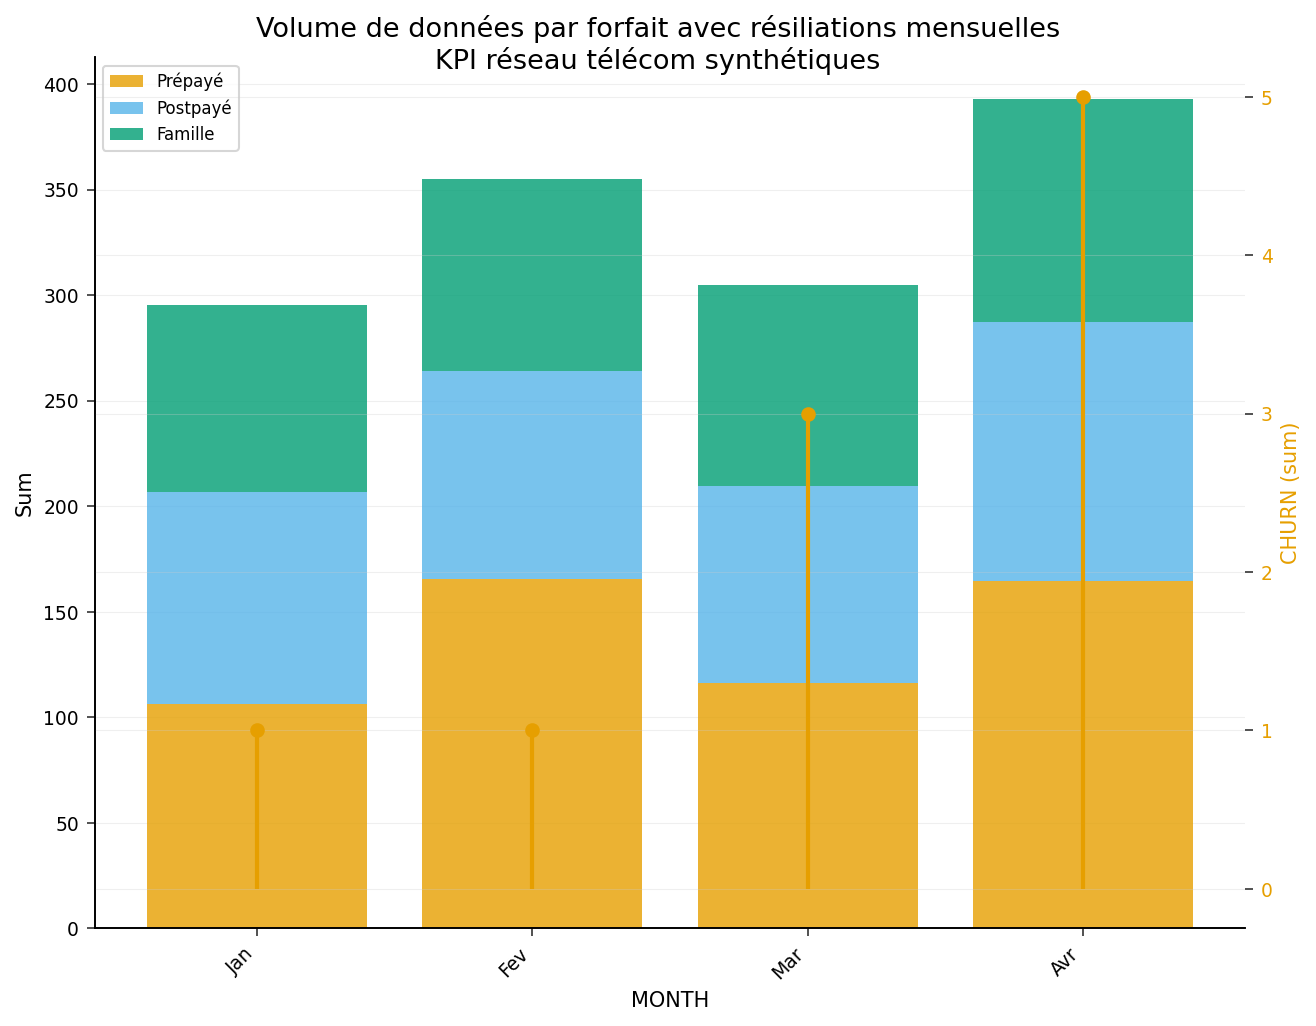

In [3]:
TITRE 'Volume de données par forfait avec résiliations mensuelles';

PROCÉDURE gbarline DONNÉES=telco_kpi;
    bar month / SUMVAR=data_gb type=sum SUBGROUP=plan;
    line churn / STAT=sum type=needle;
EXÉCUTER;

## Étape 4 — Contrôler l'axe droit et le marqueur de ligne

Pour un graphique prêt à publier, nous fixons l'axe (droit) du tracé à une plage fixe avec une définition `AXIS` et l'étiquetons, puis la lions à la ligne via `RAXIS=axis2`. Une définition `SYMBOL` donne à la ligne ARPU un marqueur pointillé rouge. Nous affichons aussi les totaux de barre au-dessus de chaque barre avec `OUTSIDE=sum`.

                                   Utilisation totale (barres) vs ARPU moyen (ligne)                                    
                                            KPI réseau télécom synthétiques                                             




NOTE: Option TITLE changed to Utilisation totale (barres) vs ARPU moyen (ligne).
NOTE: PROC GBARLINE data=telco_kpi

NOTE: ODS plot written: gbarline.spec.json


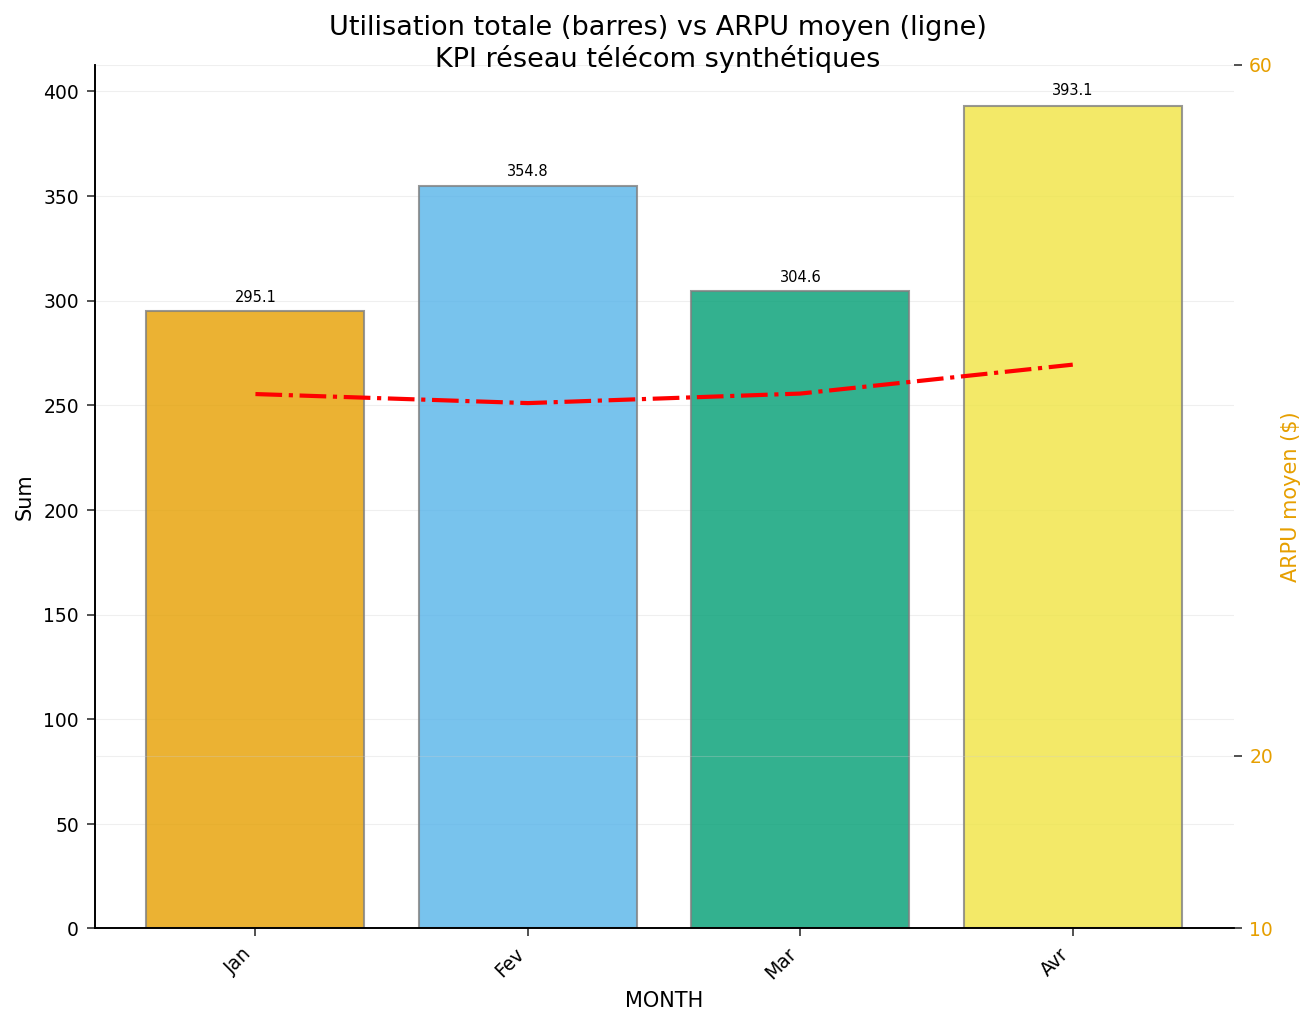

In [4]:
TITRE 'Utilisation totale (barres) vs ARPU moyen (ligne)';

PROCÉDURE gbarline DONNÉES=telco_kpi;
    axis2 ORDRE=(20 JUSQU_À 60 PAR 10) ÉTIQUETTE=('ARPU moyen ($)');
    symbol1 color=red INTERPOL=JOINDRE VALEUR=dot HEIGHT=1.4;
    bar month / SUMVAR=data_gb type=sum
                outside=sum coutline=gray;
    line arpu / STAT=mean type=JOINDRE raxis=axis2 SYMBOL=symbol1;
EXÉCUTER;

## Étape 5 — Superpositions de lignes multiples avec une légende personnalisée

`GBARLINE` accepte plus d'une instruction `LINE`, ce qui permet de comparer deux signaux opérationnels aux barres d'utilisation à la fois : la moyenne des tickets de support (`type=join`) et le total des résiliations (`type=needle`). Une définition `LEGEND` positionnée en bas documente les sous-groupes de forfait.

                                     Tickets de support et tendances de résiliation                                     
                                            KPI réseau télécom synthétiques                                             




NOTE: Option TITLE changed to Tickets de support et tendances de résiliation.
NOTE: PROC GBARLINE data=telco_kpi

NOTE: ODS plot written: gbarline.spec.json
NOTE: ODS Graphics is OFF.


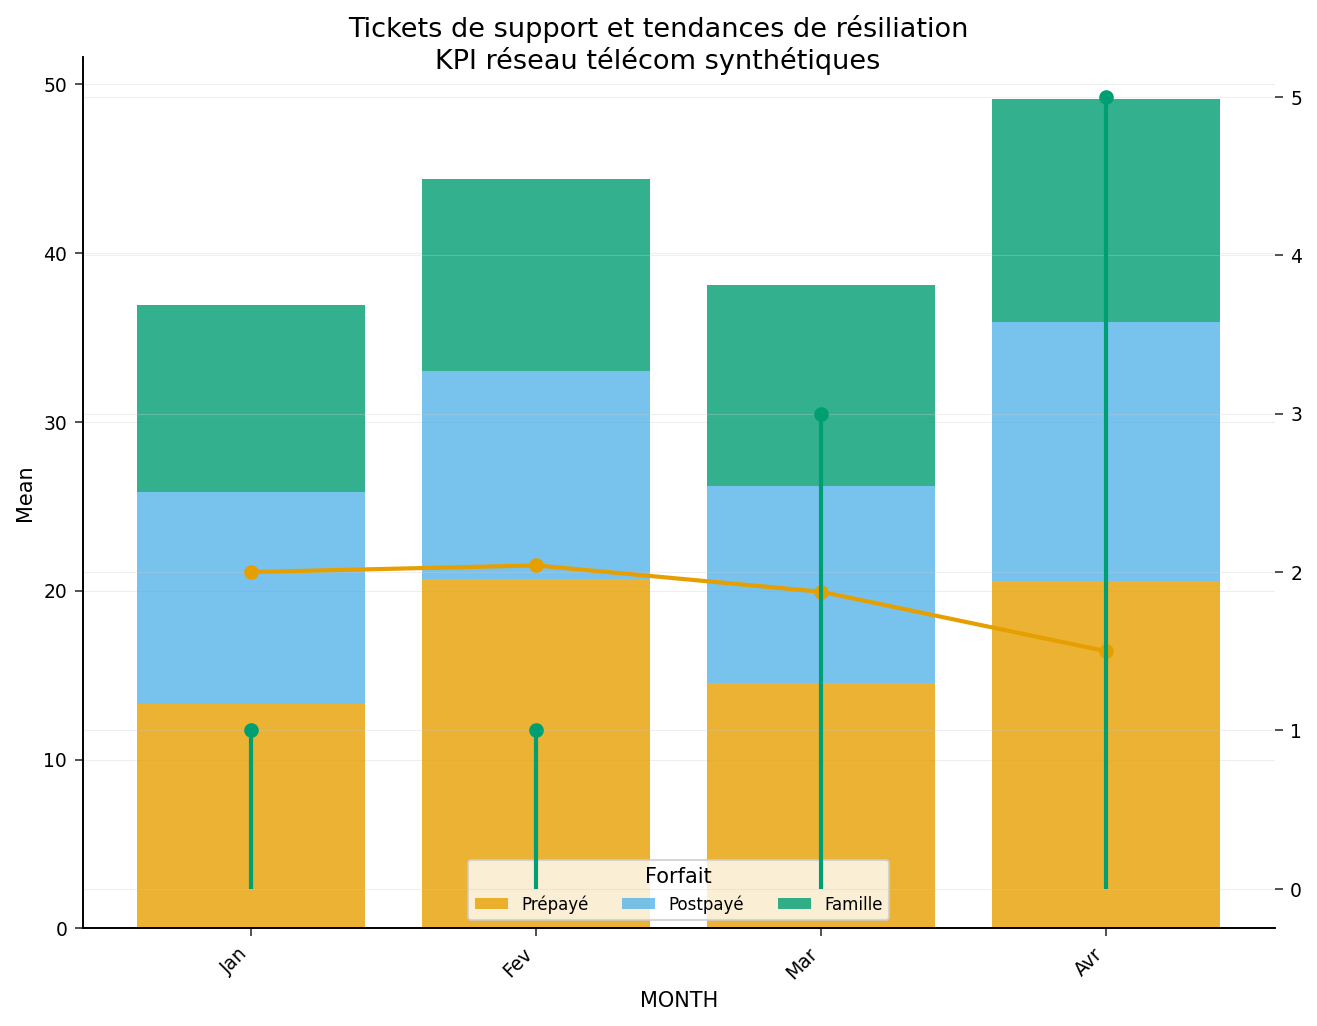

In [5]:
TITRE 'Tickets de support et tendances de résiliation';

PROCÉDURE gbarline DONNÉES=telco_kpi;
    legend1 ÉTIQUETTE=('Forfait') position=(bottom) ACROSS=3;
    bar month / SUMVAR=data_gb type=mean SUBGROUP=plan
                legend=legend1;
    line tickets / STAT=mean type=JOINDRE;
    line churn / STAT=sum type=needle;
EXÉCUTER;

ODS GRAPHICS OFF;

## Interprétation des résultats

Sur la fenêtre janvier–avril, le tableau de bord raconte une histoire télécom cohérente. **L'utilisation de données** (les barres) est irrégulière d'un mois à l'autre mais tend à la hausse, culminant en **avril** — l'utilisation moyenne grimpe d'environ 12.3 Go en janvier à 16.4 Go en avril (étape 2), et le volume total de 295 Go à 393 Go (les étiquettes `OUTSIDE=sum` à l'étape 4). **La ligne ARPU** baisse légèrement en février puis grimpe jusqu'à son propre sommet d'avril près de \$42.6, donc l'opérateur monétise de plus en plus la consommation supplémentaire plutôt que de la donner — l'axe droit à l'étape 4 est fixé entre \$20 et \$60 pour garder ce mouvement lisible.

Les vues empilées par forfait (étapes 3 et 5) révèlent la tension de segment qui définit les opérateurs à forte proportion de prépayé. **Prépayé** (la bande orange) porte le plus de gigaoctets au total — environ 553 Go sur les quatre mois contre 415 Go pour Postpayé et 380 Go pour Famille — mais génère pourtant le revenu moyen par utilisateur **le plus bas** (environ \$36, contre \$41 pour Postpayé et \$47 pour Famille). **Les aiguilles de résiliation** confirment où se situe le risque de fidélisation : les événements de résiliation se concentrent sur les forfaits Prépayé et Postpayé (4 événements chacun sur la fenêtre) et restent plus légers sur Famille (2), et ils augmentent vers avril à mesure que la base d'abonnés et l'utilisation croissent.

L'étape 5 superpose la charge opérationnelle par-dessus cela : la moyenne des **tickets de support** est un peu plus lourde en début de période et s'allège d'ici avril, tandis que les aiguilles de résiliation culminent plus tard — le type de signal qu'une équipe de fidélisation surveille. Sur le plan opérationnel, la lecture est de concentrer les dépenses de fidélisation sur les abonnés **Prépayé**, qui consomment la part de volume de données la plus rapidement croissante tout en générant le moins de revenu et le plus de résiliation.

`PROC GBARLINE` est le bon outil ici précisément parce qu'il garde les barres à l'échelle gigaoctet et les lignes à l'échelle dollar/comptage sur des axes indépendants, permettant de lire chaque KPI selon ses propres termes tout en partageant le même axe temporel mensuel.